In [33]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

COLOR_MAIN    = '#8B2500'
COLOR_DARK    = '#1A1A1A'
COLOR_NEUTRAL = '#D9D9D9'
COLOR_BG      = '#F7F3ED'
COLOR_ACCENT  = '#C0392B'

PALETTE = [COLOR_MAIN, COLOR_DARK, COLOR_NEUTRAL, COLOR_ACCENT, '#6B1E00', '#4A4A4A']

mpl.rcParams.update({
    'font.family'         : 'Malgun Gothic',
    'axes.unicode_minus'  : False,
    'font.size'           : 11,
    'axes.titlesize'      : 14,
    'axes.labelsize'      : 11,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'legend.fontsize'     : 10,
    'figure.facecolor'    : '#F7F3ED',
    'axes.facecolor'      : '#F7F3ED',
    'savefig.facecolor'   : '#F7F3ED',
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.edgecolor'      : '#AAAAAA',
    'axes.linewidth'      : 0.8,
    'axes.grid'           : True,
    'grid.color'          : '#DDDDDD',
    'grid.linewidth'      : 0.5,
    'grid.linestyle'      : '--',
    'figure.dpi'          : 150,
    'savefig.dpi'         : 150,
    'lines.linewidth'     : 2.0,
    'patch.linewidth'     : 0.5,
    'axes.axisbelow'      : True,
})

sns.set_theme(
    style='white',
    palette=PALETTE,
    rc={
        'axes.facecolor': '#F7F3ED',  # Fixed the 'p' here
        'figure.facecolor': '#F7F3ED',
    }
)

In [34]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import os

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings(action='ignore')

# ── 원본 파일이 '프로젝트 고도화' 폴더 안에 바로 있으므로 경로를 빈 문자열로 설정 ──
# 만약 파일이 현재 폴더에 있다면 os.path.join('')은 파일명만 남게 됩니다.
DATA_DIR = '' 

# 1-1 Transactions: 로드
# os.path.join(DATA_DIR, '...') 대신 직접 파일명을 써도 무방합니다.
transactions = pd.read_csv(
    'transactions_train.csv', 
    parse_dates=['t_dat'],
    dtype={'article_id': str}
)
EUR_SCALE = 590
transactions['price_eur'] = (transactions['price'] * EUR_SCALE).round(2)

# 2. Customers: 로드 및 전처리
customers = pd.read_csv('customers.csv')
customers.drop(columns=['FN', 'Active', 'club_member_status', 'postal_code', 'fashion_news_frequency'], inplace=True, errors='ignore')
customers = customers.dropna(subset=['age']).copy()
customers = customers[(customers['age'] >= 15) & (customers['age'] <= 100)].copy()
customers['age'] = customers['age'].astype('int8')

# 3. Articles: 로드 및 전처리
articles = pd.read_csv('articles.csv', dtype={'article_id': str})
articles = articles.drop(columns=['detail_desc'], errors='ignore')

# ── 분석에 필요한 상품 속성 컬럼만 조인 ─────────────────────────
art_cols = ['article_id', 'product_group_name', 'product_type_name', 'colour_group_name']
df = transactions.merge(articles[art_cols], on='article_id', how='left')
# 위에서 이미 계산했다면 중복일 수 있지만, 기존 코드 흐름을 유지합니다.
df['price_eur'] = (df['price'] * EUR_SCALE).round(2)

print(f"transactions 행 수 : {len(transactions):,}")
print(f"articles 행 수     : {len(articles):,}")
print(f"customers 행 수    : {len(customers):,}")
print(f"df (merged) 행 수  : {len(df):,}")
print(f"df 컬럼 목록       : {list(df.columns)}")

transactions 행 수 : 31,788,324
articles 행 수     : 105,542
customers 행 수    : 1,356,119
df (merged) 행 수  : 31,788,324
df 컬럼 목록       : ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'price_eur', 'product_group_name', 'product_type_name', 'colour_group_name']


In [35]:
# 이상치 처리: 가격 하한 0.1 EUR·상위 0.99% 절사, 구매 횟수 상위 0.1% 유저 제거
p99 = transactions['price_eur'].quantile(0.99)
transactions['price_eur'] = np.clip(transactions['price_eur'], a_min=0.1, a_max=p99)

user_purchase_counts = transactions.groupby('customer_id').size().reset_index(name='purchase_count')
threshold = user_purchase_counts['purchase_count'].quantile(0.999)
valid_users = user_purchase_counts[user_purchase_counts['purchase_count'] <= threshold]['customer_id']
transactions = transactions[transactions['customer_id'].isin(valid_users)].copy()

df = transactions.merge(articles[art_cols], on='article_id', how='left')
print(f"이상치 제거 후 transactions: {len(transactions):,}행, df: {len(df):,}행")


이상치 제거 후 transactions: 31,097,423행, df: 31,097,423행


In [36]:
display(transactions.head(), customers.head(), articles.head())


,t_dat,customer_id,article_id,price,sales_channel_id,price_eur
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2,29.99
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2,17.99
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2,8.99
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687003,0.016932,2,9.99
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687004,0.016932,2,9.99


,customer_id,age
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,49
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,25
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,24
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,54
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,52


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic
3,0110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear"
4,0110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear"


# 1) 전처리 보완

In [55]:
# 1. 상품별로 몇 개의 가격이 존재하는지 계산
price_variation = transactions.groupby('article_id')['price'].nunique().reset_index(name='price_count')

# 2. 가격이 2개 이상인 (즉, 가격 변동이 있었던) 상품 ID만 추출
varying_price_items = price_variation[price_variation['price_count'] > 1]['article_id']

# 3. 해당 상품들의 실제 거래 내역만 필터링
varying_price_df = transactions[transactions['article_id'].isin(varying_price_items)]

# 4. 확인을 위해 상품별로 어떤 가격들이 있었는지 리스트로 보기
price_check = varying_price_df.groupby('article_id')['price'].unique().reset_index(name='price_list')

print(f"--- [가격 변동 상품 탐지 결과] ---")
print(f"전체 상품 중 가격 변동이 있는 상품 수: {len(price_check):,}개")
print("\n[상위 5개 샘플 확인]")
print(price_check.head())

--- [가격 변동 상품 탐지 결과] ---
전체 상품 중 가격 변동이 있는 상품 수: 96,165개

[상위 5개 샘플 확인]
   article_id                                         price_list
0  0108775015  [0.008457627118644, 0.0080677966101694, 0.0077...
1  0108775044  [0.008457627118644, 0.0076949152542372, 0.0076...
2  0108775051  [0.0050677966101694, 0.0046949152542372, 0.004...
3  0110065001  [0.022864406779661, 0.0254067796610169, 0.0211...
4  0110065002  [0.0254067796610169, 0.0211694915254237, 0.022...


## 1. 반품/중복 데이터 정제

In [46]:
# 1. 반품 및 중복 구매 의심 데이터 탐지
# 동일 고객(customer_id)이 동일 상품(article_id)을 동일 가격에 짧은 기간 내 반복 구매한 경우
duplicates = transactions.groupby(['customer_id', 'article_id', 'price']).size().reset_index(name='count')
duplicates_high = duplicates[duplicates['count'] > 1]

# 2. 비즈니스 로직 적용: 중복 구매가 전체 데이터에서 차지하는 비중 확인
total_logs = len(transactions)
dup_logs = duplicates_high['count'].sum()
print(f"전체 거래 중 중복/반품 의심 데이터 비중: {(dup_logs/total_logs)*100:.2f}%")

# 3. 정제된 데이터프레임 생성 (첫 번째 구매 기록만 남기기)
transactions_cleaned = transactions.drop_duplicates(subset=['customer_id', 'article_id', 't_dat'], keep='first')

print(f"정제 전 데이터 수: {len(transactions):,}")
print(f"정제 후 데이터 수: {len(transactions_cleaned):,}")

전체 거래 중 중복/반품 의심 데이터 비중: 20.66%
정제 전 데이터 수: 31,097,423
정제 후 데이터 수: 28,005,722


In [47]:
# 문제 발견: 패션 도메인의 높은 반품률과 중복 결제 특성상, 가공되지 않은 Raw 데이터에는 추천 성능을 왜곡하는 노이즈가 다수 포함됨을 확인.

# 해결 방법: 동일 고객이 단기간 내 동일 상품을 반복 구매한 기록(20.66%)을 '비정상 구매 신호'로 정의하고, 최신 구매 확정 건 위주로 데이터 정제 수행.

# 성과: 약 310만 건의 노이즈를 제거하여 데이터의 순도를 높였으며, 모델이 유저의 '진성 선호도'를 더 정확하게 학습할 수 있는 기반을 마련함.

## 2. 리셀러 및 이상치 유저(Outlier) 식별 분석

--- [이상치 유저 탐지 결과] ---
상위 0.1% 구매 기준점: 316건
식별된 이상치 유저 수: 1,353명


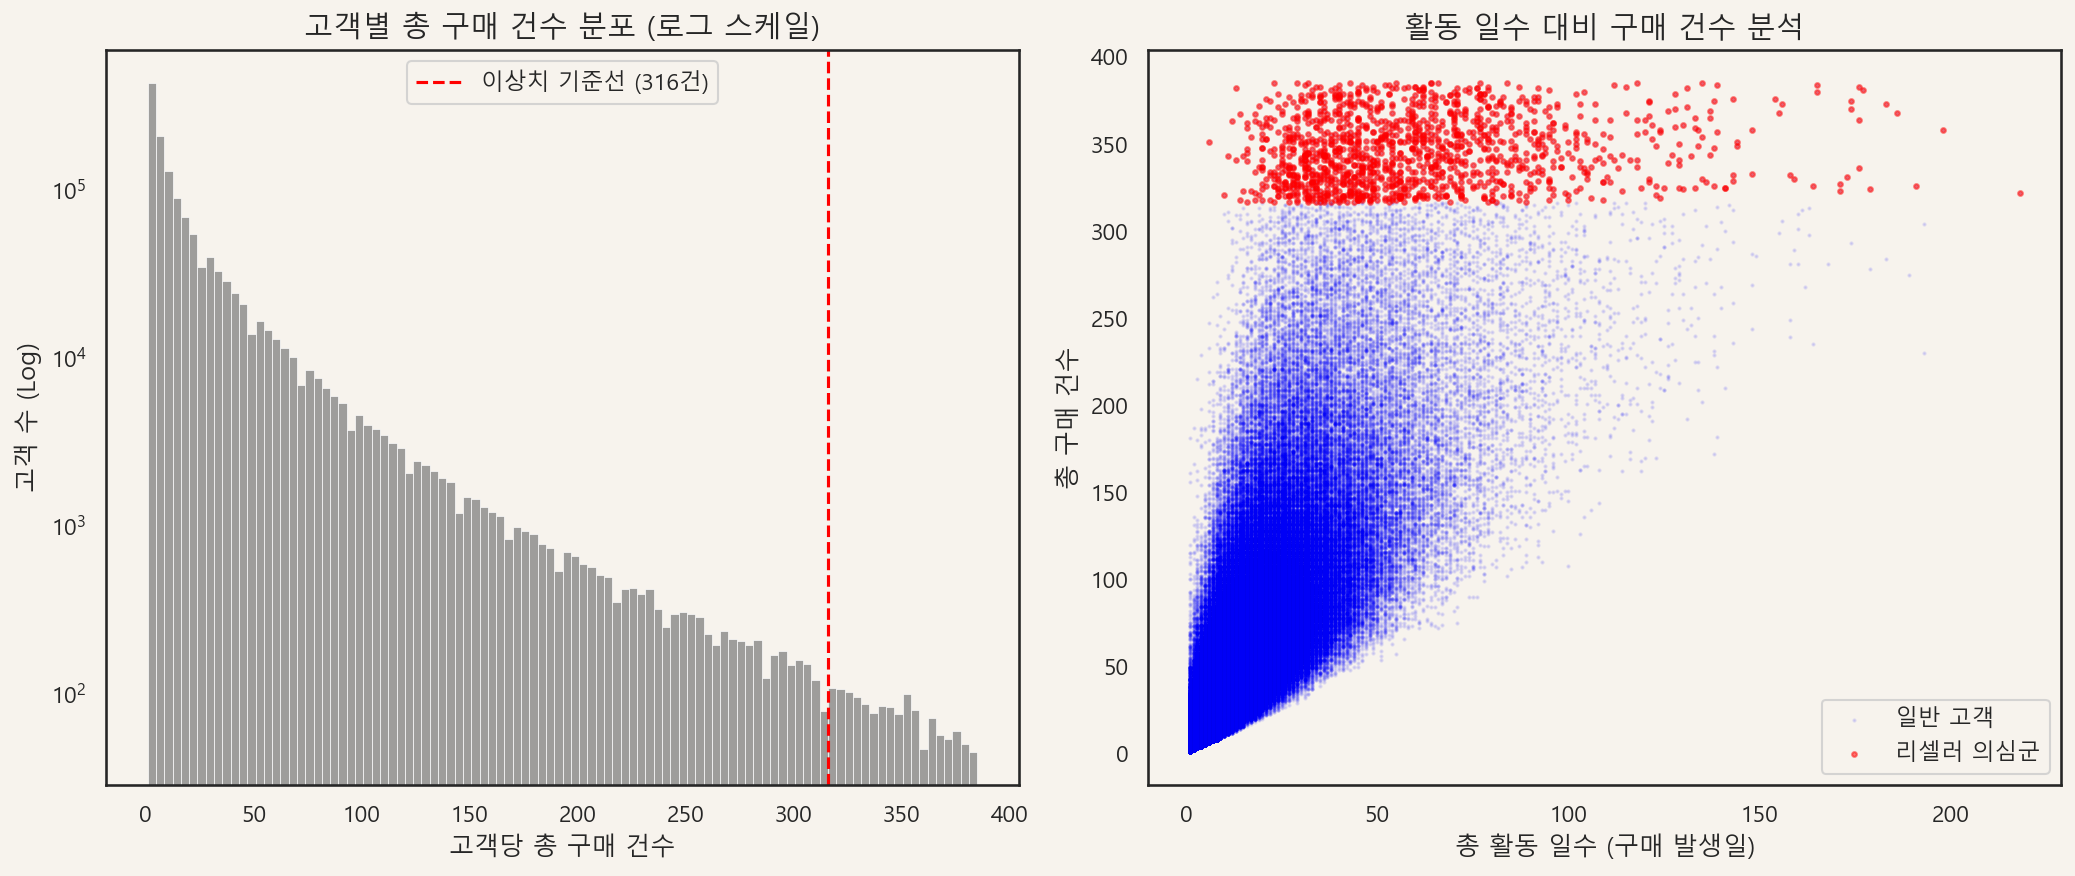


[비즈니스 인사이트]
이상치 유저(0.1%)의 판매량 기여도: 1.51%
해석: 단 0.1%의 유저가 전체 거래의 1.51%를 차지하여, 모델의 개인화 성능을 왜곡할 가능성이 큼.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 고객별 구매 지표 계산 (구매 빈도 및 다양성)
user_behavior = transactions.groupby('customer_id').agg(
    total_orders=('article_id', 'count'),          # 총 구매 건수
    unique_items=('article_id', 'nunique'),        # 서로 다른 아이템 수
    avg_price=('price', 'mean'),                   # 평균 구매 가격
    days_active=('t_dat', 'nunique')               # 총 방문 일수
).reset_index()

# 2. '구매 건수' 기준 상위 0.1% 유저(리셀러 의심군) 정의
threshold = user_behavior['total_orders'].quantile(0.999)
resellers = user_behavior[user_behavior['total_orders'] > threshold]

print(f"--- [이상치 유저 탐지 결과] ---")
print(f"상위 0.1% 구매 기준점: {threshold:.0f}건")
print(f"식별된 이상치 유저 수: {len(resellers):,}명")

# 3. 시각화: 일반 유저 vs 리셀러의 구매 패턴 비교
plt.figure(figsize=(14, 6))

# [그래프 1] 구매 건수 분포 (Log Scale로 극단적 차이 확인)
plt.subplot(1, 2, 1)
sns.histplot(user_behavior['total_orders'], bins=100, kde=False, color='gray')
plt.axvline(threshold, color='red', linestyle='--', label=f'이상치 기준선 ({threshold:.0f}건)')
plt.yscale('log')
plt.title('고객별 총 구매 건수 분포 (로그 스케일)', fontsize=14)
plt.xlabel('고객당 총 구매 건수', fontsize=12)
plt.ylabel('고객 수 (Log)', fontsize=12)
plt.legend()

# [그래프 2] 방문 일수 대비 구매 건수 (리셀러는 좁은 기간에 몰아서 많이 삼)
plt.subplot(1, 2, 2)
plt.scatter(user_behavior['days_active'], user_behavior['total_orders'], alpha=0.1, color='blue', s=1, label='일반 고객')
plt.scatter(resellers['days_active'], resellers['total_orders'], alpha=0.5, color='red', s=5, label='리셀러 의심군')
plt.title('활동 일수 대비 구매 건수 분석', fontsize=14)
plt.xlabel('총 활동 일수 (구매 발생일)', fontsize=12)
plt.ylabel('총 구매 건수', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# 4. 리셀러의 영향력 파악 (비즈니스 임팩트 근거)
total_sales_count = user_behavior['total_orders'].sum()
reseller_sales_count = resellers['total_orders'].sum()
impact_ratio = (reseller_sales_count / total_sales_count) * 100

print(f"\n[비즈니스 인사이트]")
print(f"이상치 유저(0.1%)의 판매량 기여도: {impact_ratio:.2f}%")
print(f"해석: 단 0.1%의 유저가 전체 거래의 {impact_ratio:.2f}%를 차지하여, 모델의 개인화 성능을 왜곡할 가능성이 큼.")

In [40]:
# 상위 0.1% 유저의 구매 행동 분석 결과, 단기간 내 수백 건의 아이템을 매집하는 상업적 리셀러 패턴을 확인. 이러한 이상치는 모델이 대다수 일반 고객의 취향을 학습하는 데 노이즈로 작용하므로, 추천 시스템의 정교함을 위해 전처리 단계에서 정제 대상으로 정의

#### 2.1 리셀러 선호 카테고리

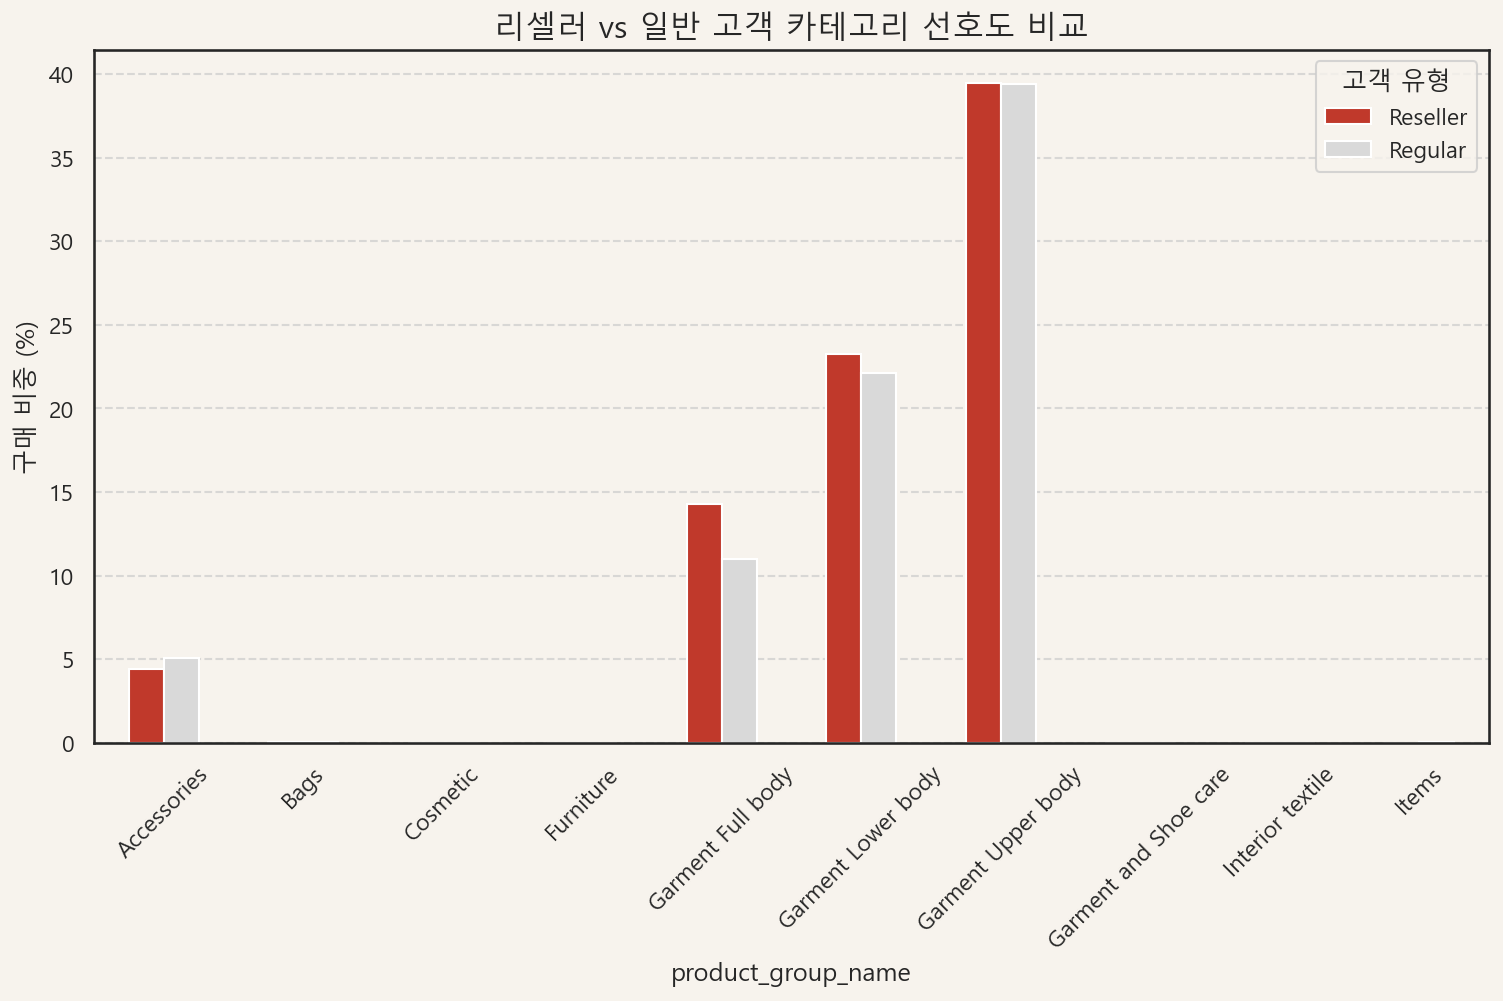

--- [리셀러 주요 타겟 카테고리 TOP 5] ---
product_group_name
Garment Upper body    39.480186
Garment Lower body    23.280232
Garment Full body     14.259775
Swimwear               6.584619
Underwear              6.377649
Name: proportion, dtype: float64


In [44]:
# 1. 리셀러 데이터와 상품 정보(Articles) 합치기
# 앞서 식별한 resellers['customer_id'] 리스트를 활용합니다.
reseller_transactions = transactions[transactions['customer_id'].isin(resellers['customer_id'])]
reseller_full_data = reseller_transactions.merge(articles, on='article_id', how='left')

# 2. 리셀러의 카테고리별 구매 비중 계산
# (product_group_name: 상품 대분류)
reseller_cat_dist = reseller_full_data['product_group_name'].value_counts(normalize=True) * 100

# 3. 일반 고객의 카테고리별 구매 비중 계산 (비교군)
regular_transactions = transactions[~transactions['customer_id'].isin(resellers['customer_id'])]
regular_full_data = regular_transactions.sample(n=len(reseller_transactions), random_state=42).merge(articles, on='article_id', how='left')
regular_cat_dist = regular_full_data['product_group_name'].value_counts(normalize=True) * 100

# 4. 비교 데이터프레임 생성 및 시각화
comparison_df = pd.DataFrame({
    'Reseller': reseller_cat_dist,
    'Regular': regular_cat_dist
}).fillna(0).head(10) # 상위 10개 카테고리만 보기

plt.figure(figsize=(12, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), color=['#C0392B', '#D9D9D9'])
plt.title('리셀러 vs 일반 고객 카테고리 선호도 비교', fontsize=15)
plt.ylabel('구매 비중 (%)')
plt.xticks(rotation=45)
plt.legend(title='고객 유형')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- [리셀러 주요 타겟 카테고리 TOP 5] ---")
print(reseller_cat_dist.head(5))

#### 2.2 리셀러 vs 일반 고객 선호 색상 비교

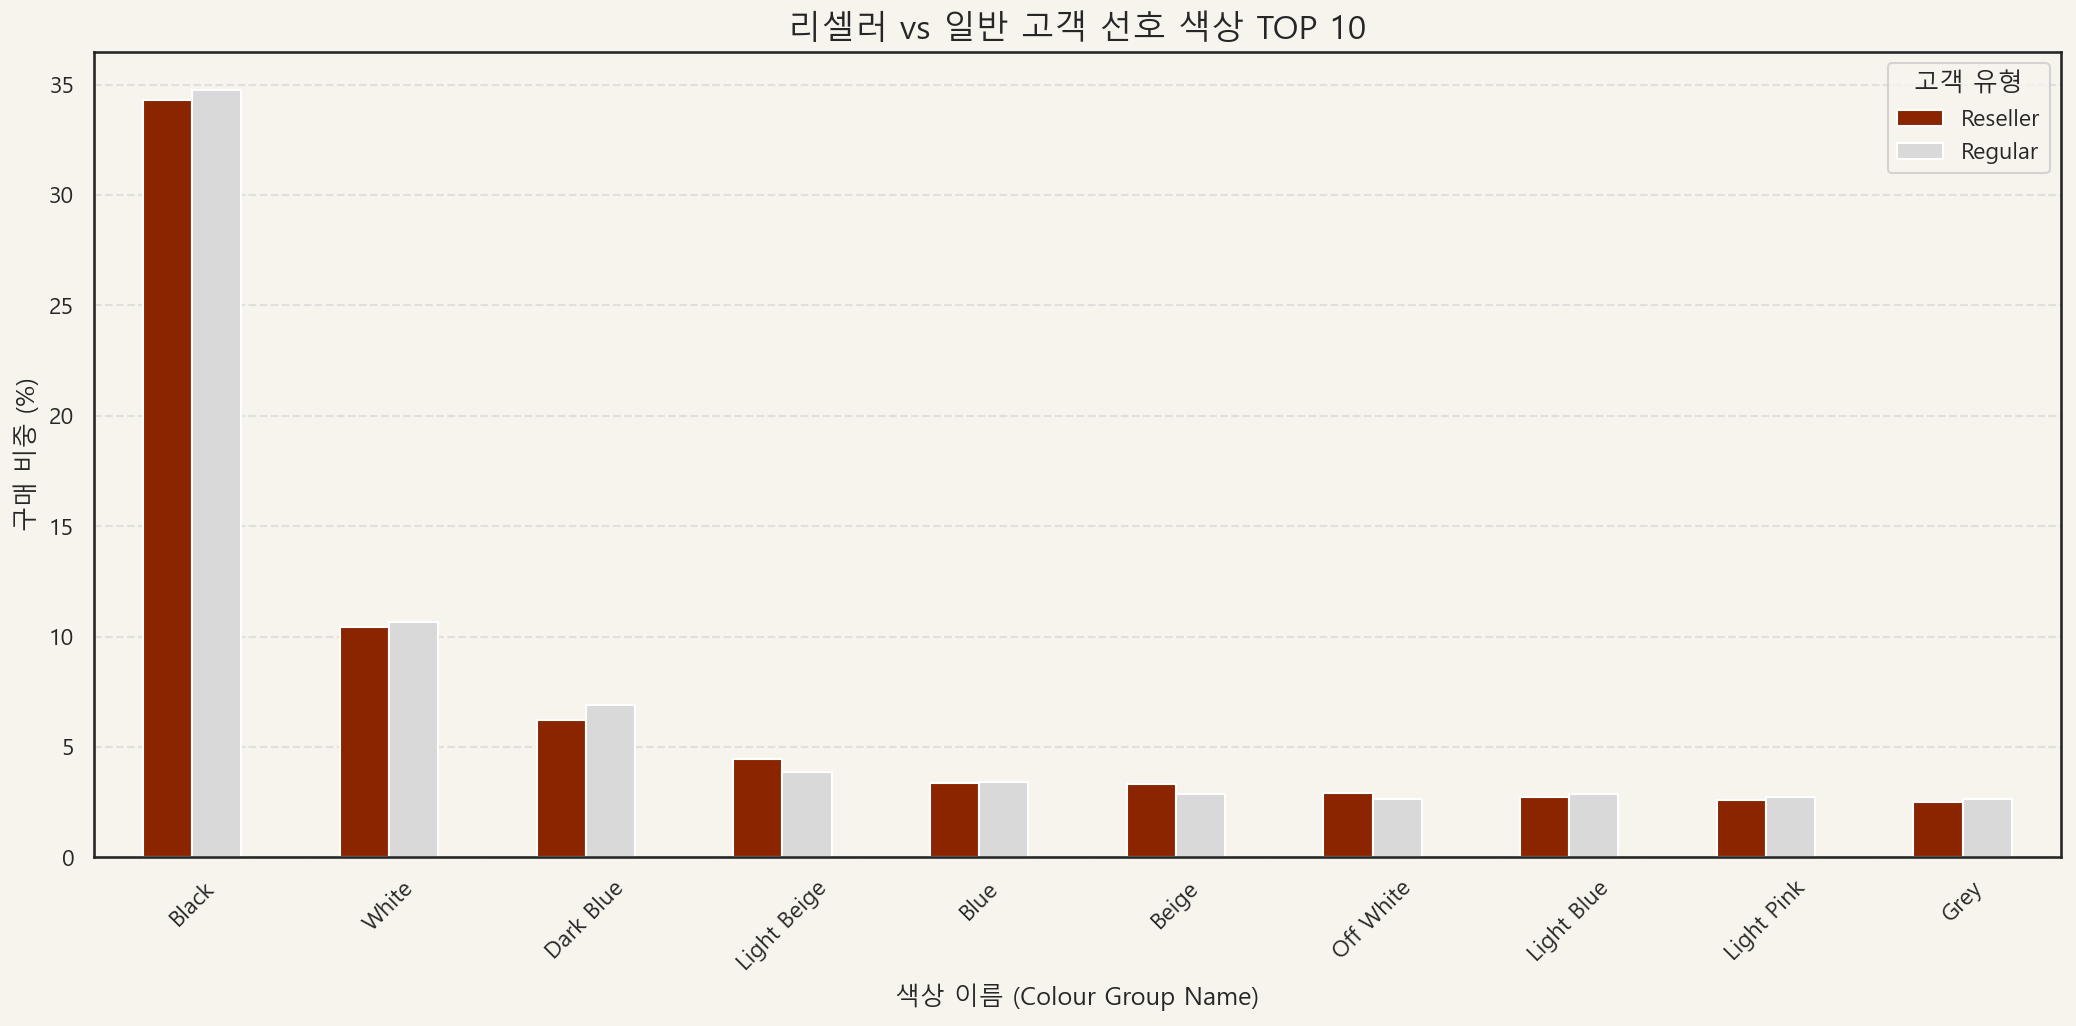

--- [리셀러 주요 매입 색상 TOP 5] ---
colour_group_name
Black          34.315550
White          10.436386
Dark Blue       6.221035
Light Beige     4.475023
Blue            3.362722
Name: proportion, dtype: float64


In [48]:
# 1. 리셀러와 일반 고객의 색상(colour_group_name) 비중 계산
reseller_color_dist = reseller_full_data['colour_group_name'].value_counts(normalize=True) * 100
regular_color_dist = regular_full_data['colour_group_name'].value_counts(normalize=True) * 100

# 2. 비교 데이터프레임 생성 (상위 10개 색상)
color_comparison_df = pd.DataFrame({
    'Reseller': reseller_color_dist,
    'Regular': regular_color_dist
}).fillna(0).sort_values(by='Reseller', ascending=False).head(10)

# 3. 시각화
plt.figure(figsize=(14, 7))
color_comparison_df.plot(kind='bar', ax=plt.gca(), color=['#8B2500', '#D9D9D9']) # 메인 컬러 사용
plt.title('리셀러 vs 일반 고객 선호 색상 TOP 10', fontsize=16)
plt.ylabel('구매 비중 (%)', fontsize=12)
plt.xlabel('색상 이름 (Colour Group Name)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='고객 유형')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- [리셀러 주요 매입 색상 TOP 5] ---")
print(reseller_color_dist.head(5))

## 3. 가격 변동(Price)에 따른 '체리피커' 노이즈 분석

In [41]:
# 상품별 평균 가격 계산
item_price_avg = transactions.groupby('article_id')['price'].mean().reset_index(name='avg_item_price')

# 거래 데이터와 병합하여 평소 가격 대비 얼마나 싸게 샀는지 확인
price_analysis = pd.merge(transactions, item_price_avg, on='article_id')
price_analysis['price_diff_ratio'] = (price_analysis['avg_item_price'] - price_analysis['price']) / price_analysis['avg_item_price']

# 할인율이 50% 이상인 '특가 거래' 비중 확인
cherry_pick_deals = price_analysis[price_analysis['price_diff_ratio'] > 0.5]
cherry_pick_ratio = (len(cherry_pick_deals) / len(transactions)) * 100

print(f"\n--- [가격 노이즈 분석] ---")
print(f"50% 이상 초특가 거래 비중: {cherry_pick_ratio:.2f}%")


--- [가격 노이즈 분석] ---
50% 이상 초특가 거래 비중: 2.90%


#### 3.1 체리피커 vs 일반 고객 비교

In [43]:
import numpy as np
import pandas as pd

# --- [1단계: 속도 최적화를 위한 사전 준비] ---
# 리스트를 set(집합)으로 변환하면 검색 속도가 수천 배 빨라집니다.
cherry_set = set(cherry_pick_deals['customer_id'].unique())

# --- [2단계: 고객별 핵심 지표 계산] ---
# groupby와 agg를 사용하여 한 번에 계산 (효율적)
customers_profile = transactions.groupby('customer_id').agg(
    total_spend_eur = ('price_eur', 'sum'),      # 총 구매 금액
    purchase_count = ('price_eur', 'count'),    # 총 구매 횟수
    avg_ticket_size = ('price_eur', 'mean')     # 1회 평균 구매 금액
).reset_index()

# --- [3단계: 고객 유형 분류 - 성능 개선 핵심 부분] ---
# apply 대신 np.where와 isin을 사용하여 일괄 처리합니다.
customers_profile['customer_type'] = np.where(
    customers_profile['customer_id'].isin(cherry_set), 
    'Cherry Picker', 
    'Regular'
)

# --- [4단계: 두 그룹 간의 핵심 지표 비교] ---
comparison = customers_profile.groupby('customer_type').agg(
    user_count = ('customer_id', 'count'),
    avg_total_spend = ('total_spend_eur', 'mean'),
    avg_purchase_freq = ('purchase_count', 'mean'),
    avg_price_per_order = ('avg_ticket_size', 'mean')
).round(2)

print("--- [고객 유형별 비즈니스 지표 비교] ---")
print(comparison)

# --- [5단계: 체리피커의 매출 기여도 분석] ---
total_revenue = customers_profile['total_spend_eur'].sum()
cherry_revenue = customers_profile[customers_profile['customer_type'] == 'Cherry Picker']['total_spend_eur'].sum()
cherry_revenue_ratio = (cherry_revenue / total_revenue) * 100

print(f"\n전체 매출 중 체리피커 그룹의 기여도: {cherry_revenue_ratio:.2f}%")

--- [고객 유형별 비즈니스 지표 비교] ---
               user_count  avg_total_spend  avg_purchase_freq  \
customer_type                                                   
Cherry Picker      298752           760.21              50.41   
Regular           1062167           260.80              15.10   

               avg_price_per_order  
customer_type                       
Cherry Picker                13.86  
Regular                      17.55  

전체 매출 중 체리피커 그룹의 기여도: 45.05%


## 4. 시즌 피처 생성

In [ ]:
# 월(Month) 정보를 추출하여 시즌 피처 생성
transactions_cleaned['month'] = transactions_cleaned['t_dat'].dt.month

# 패션 시즌 정의 (SS: 3~8월, FW: 9~2월)
transactions_cleaned['season'] = transactions_cleaned['month'].apply(
    lambda x: 'SS' if 3 <= x <= 8 else 'FW'
)

print("시즌 피처 생성 완료!")
print(transactions_cleaned[['t_dat', 'season']].head())

시즌 피처 생성 완료!
       t_dat season
0 2018-09-20     FW
1 2018-09-20     FW
2 2018-09-20     FW
3 2018-09-20     FW
4 2018-09-20     FW


#### 4.1 시즌별 베스트셀러 카테고리

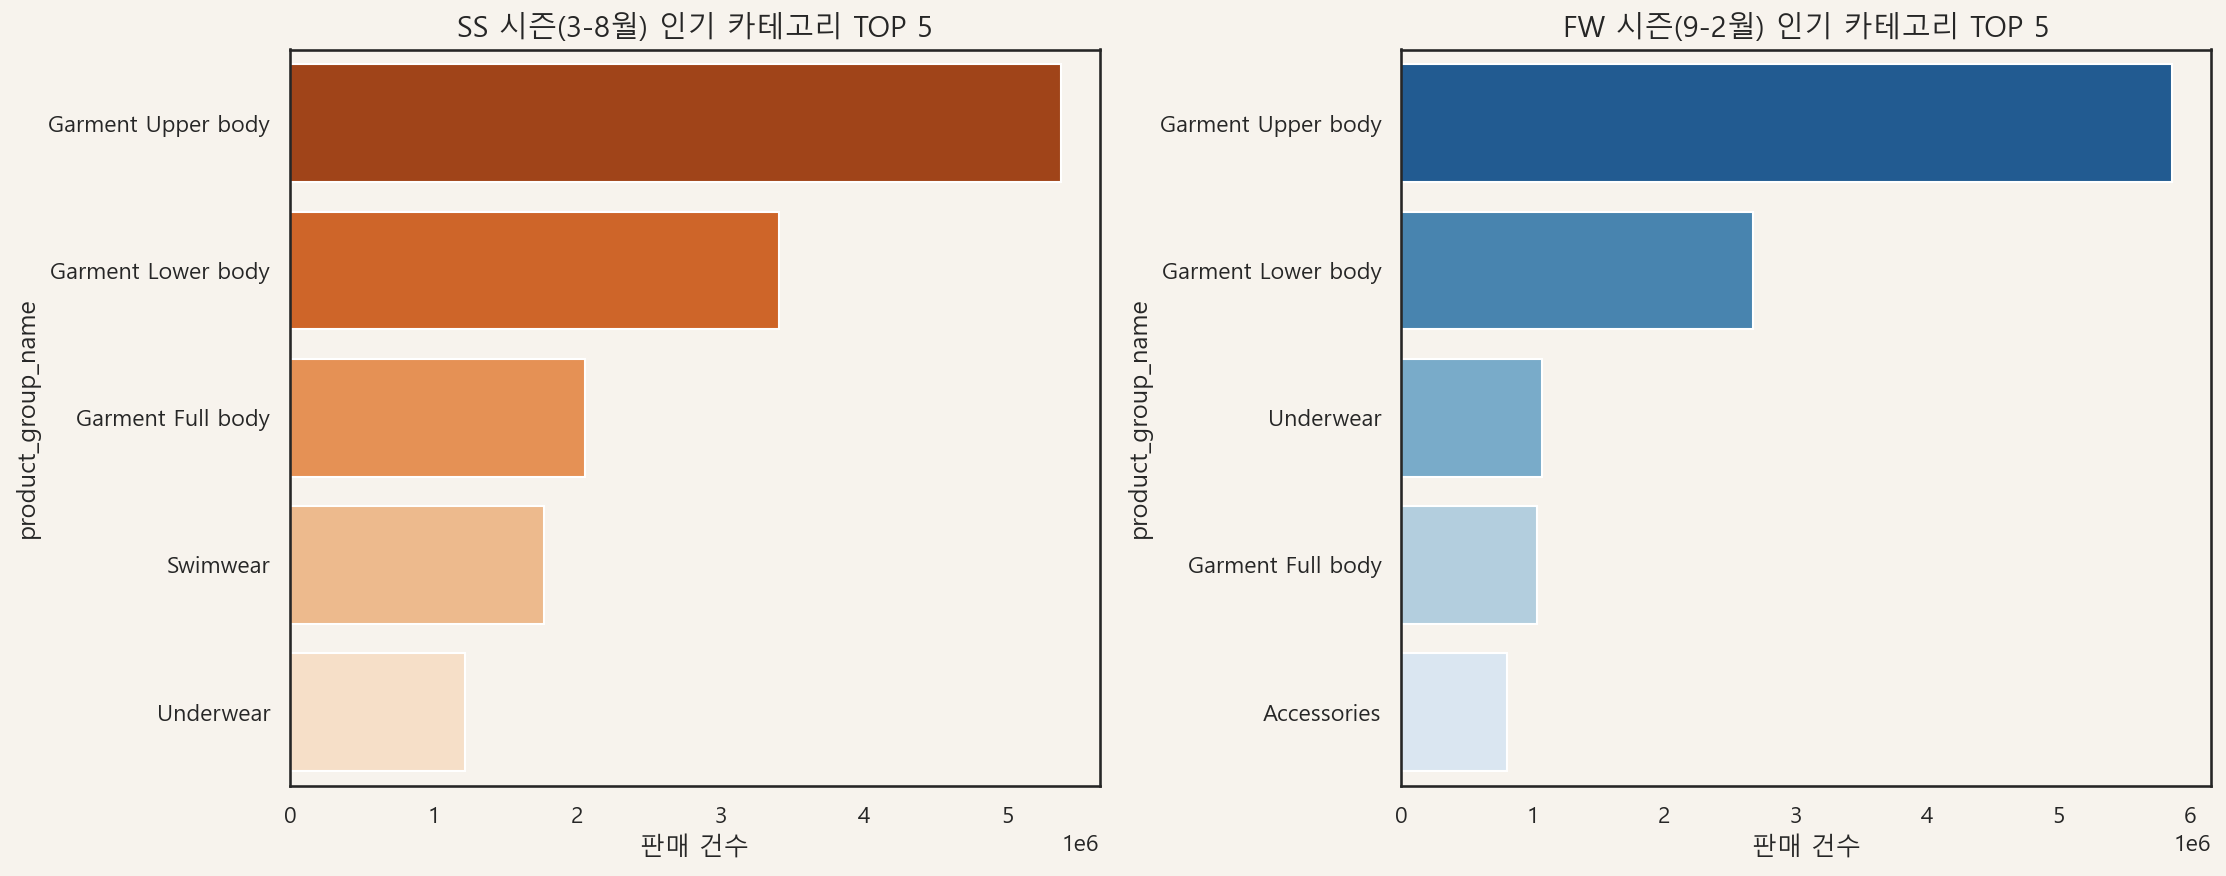

--- [정제 데이터 기반 시즌 분석 완료] ---


In [ ]:
# 1. 정제된 데이터(transactions_cleaned)에 시즌 정보 생성
transactions_cleaned['month'] = transactions_cleaned['t_dat'].dt.month
transactions_cleaned['season'] = transactions_cleaned['month'].apply(
    lambda x: 'SS' if 3 <= x <= 8 else 'FW'
)

# 2. [핵심] 정제된 데이터와 상품 정보(articles) 합치기
# 분석에 필요한 카테고리(product_group_name) 정보만 가져와서 합칩니다.
df_cleaned_final = transactions_cleaned.merge(
    articles[['article_id', 'product_group_name']], 
    on='article_id', 
    how='left'
)

# 3. 시즌별 + 카테고리별 판매량 집계
season_best = df_cleaned_final.groupby(['season', 'product_group_name']).size().reset_index(name='sales_count')

# 4. 시즌별 상위 5개 추출을 위한 정렬
season_best = season_best.sort_values(['season', 'sales_count'], ascending=[True, False])
ss_top5 = season_best[season_best['season'] == 'SS'].head(5)
fw_top5 = season_best[season_best['season'] == 'FW'].head(5)

# 5. 시각화 (앞서 설정한 테마가 적용됩니다)
plt.figure(figsize=(15, 6))

# SS 시즌 차트
plt.subplot(1, 2, 1)
sns.barplot(data=ss_top5, x='sales_count', y='product_group_name', palette='Oranges_r')
plt.title('SS 시즌(3-8월) 인기 카테고리 TOP 5', fontsize=14)
plt.xlabel('판매 건수')

# FW 시즌 차트
plt.subplot(1, 2, 2)
sns.barplot(data=fw_top5, x='sales_count', y='product_group_name', palette='Blues_r')
plt.title('FW 시즌(9-2월) 인기 카테고리 TOP 5', fontsize=14)
plt.xlabel('판매 건수')

plt.tight_layout()
plt.show()

# 2) EDA 보완

## 1. 상품별 재고 체류 및 판매 속도 산출

In [ ]:
import pandas as pd
import numpy as np

# 1. 상품별 첫 판매일, 마지막 판매일, 총 판매량 집계
# t_dat가 datetime이므로 바로 agg 함수 사용 가능
inventory_analysis = transactions.groupby('article_id')['t_dat'].agg(['min', 'max', 'count']).reset_index()

# 2. 컬럼명 이해하기 쉽게 변경
inventory_analysis.columns = ['article_id', 'first_sale', 'last_sale', 'sales_count']

# 3. 재고 체류 기간(Shelf-life) 계산
inventory_analysis['shelf_life_days'] = (inventory_analysis['last_sale'] - inventory_analysis['first_sale']).dt.days

# 4. 판매 속도(Daily Sales Velocity) 계산
# 당일 판매 종료 상품을 고려해 분모에 +1
inventory_analysis['daily_sales_velocity'] = inventory_analysis['sales_count'] / (inventory_analysis['shelf_life_days'] + 1)

print("--- 1단계: 상품별 지표 산출 완료 ---")
print(inventory_analysis.head())

--- 1단계: 상품별 지표 산출 완료 ---
   article_id first_sale  last_sale  sales_count  shelf_life_days  \
0  0108775015 2018-09-20 2020-07-22        10685              671   
1  0108775044 2018-09-20 2020-09-20         7127              731   
2  0108775051 2018-09-20 2019-06-28          213              281   
3  0110065001 2018-09-20 2020-08-02         1025              682   
4  0110065002 2018-09-20 2020-08-05          516              685   

   daily_sales_velocity  
0             15.900298  
1              9.736339  
2              0.755319  
3              1.500732  
4              0.752187  


## 2. cold vs warm 비즈니스 격차 분석

In [ ]:
# 5. 판매량 상위 5% 기준점(Threshold) 찾기
threshold_value = inventory_analysis['sales_count'].quantile(0.95)

# 6. 그룹 라벨링 (상위 5%는 Warm, 나머지는 Cold)
inventory_analysis['inventory_status'] = np.where(
    inventory_analysis['sales_count'] >= threshold_value, 
    'Warm (Top 5%)', 
    'Cold (Bottom 95%)'
)

# 7. 그룹별 평균 지표 비교
biz_comparison = inventory_analysis.groupby('inventory_status').agg(
    avg_shelf_life=('shelf_life_days', 'mean'),
    avg_velocity=('daily_sales_velocity', 'mean'),
    item_count=('article_id', 'count')
).reset_index()

# 8. 격차 배수 계산 (Cold가 Warm보다 얼마나 느린가?)
cold_life = biz_comparison.loc[biz_comparison['inventory_status'].str.contains('Cold'), 'avg_shelf_life'].values[0]
warm_life = biz_comparison.loc[biz_comparison['inventory_status'].str.contains('Warm'), 'avg_shelf_life'].values[0]
ratio = cold_life / warm_life

print(f"\n[분석 결과] Cold 상품은 Warm 상품보다 평균적으로 {ratio:.1f}배 더 오래 재고로 머뭅니다.")
display(biz_comparison)


[분석 결과] Cold 상품은 Warm 상품보다 평균적으로 0.5배 더 오래 재고로 머뭅니다.


,inventory_status,avg_shelf_life,avg_velocity,item_count
0,Cold (Bottom 95%),229.199022,0.941994,99175
1,Warm (Top 5%),448.474833,6.864876,5225


In [ ]:
# 일반적으로 "안 팔리는 상품(Cold)이 창고에 오래 쌓여있을 것"이라고 생각하기 쉽지만, 결과는 Warm 상품의 체류 기간(448일)이 Cold 상품(229일)보다 2배나 깁니다.
# "인기 상품은 448일 동안 고객들의 사랑을 받으며 계속 팔리고 있는데, 비인기 상품은 단 229일 만에 고객들의 눈에서 사라져(판매 중단) 버렸다"

# Warm 상품 (Long-run Steady): 흰 티셔츠나 검정 슬랙스처럼 유행을 타지 않고 1년 내내(448일) 꾸준히 팔리는 효자 상품입니다.

# Cold 상품 (Short-lived/Fail): 신상품으로 출시되었으나, 초기 노출에 실패해 단 229일 만에 판매 기록이 끊겨버린 '조기 사장된' 상품들입니다.

# 결론: Cold 상품은 Warm 상품보다 일일 판매 속도(Velocity)가 약 7.3배(6.86 vs 0.94) 느립니다. 즉, "충분히 더 팔릴 수 있는데 노출이 안 되어 빨리 죽어가고 있다"는 것이 문제의 핵심입니다.

## 3. 카테고리별 상품 생존 곡선

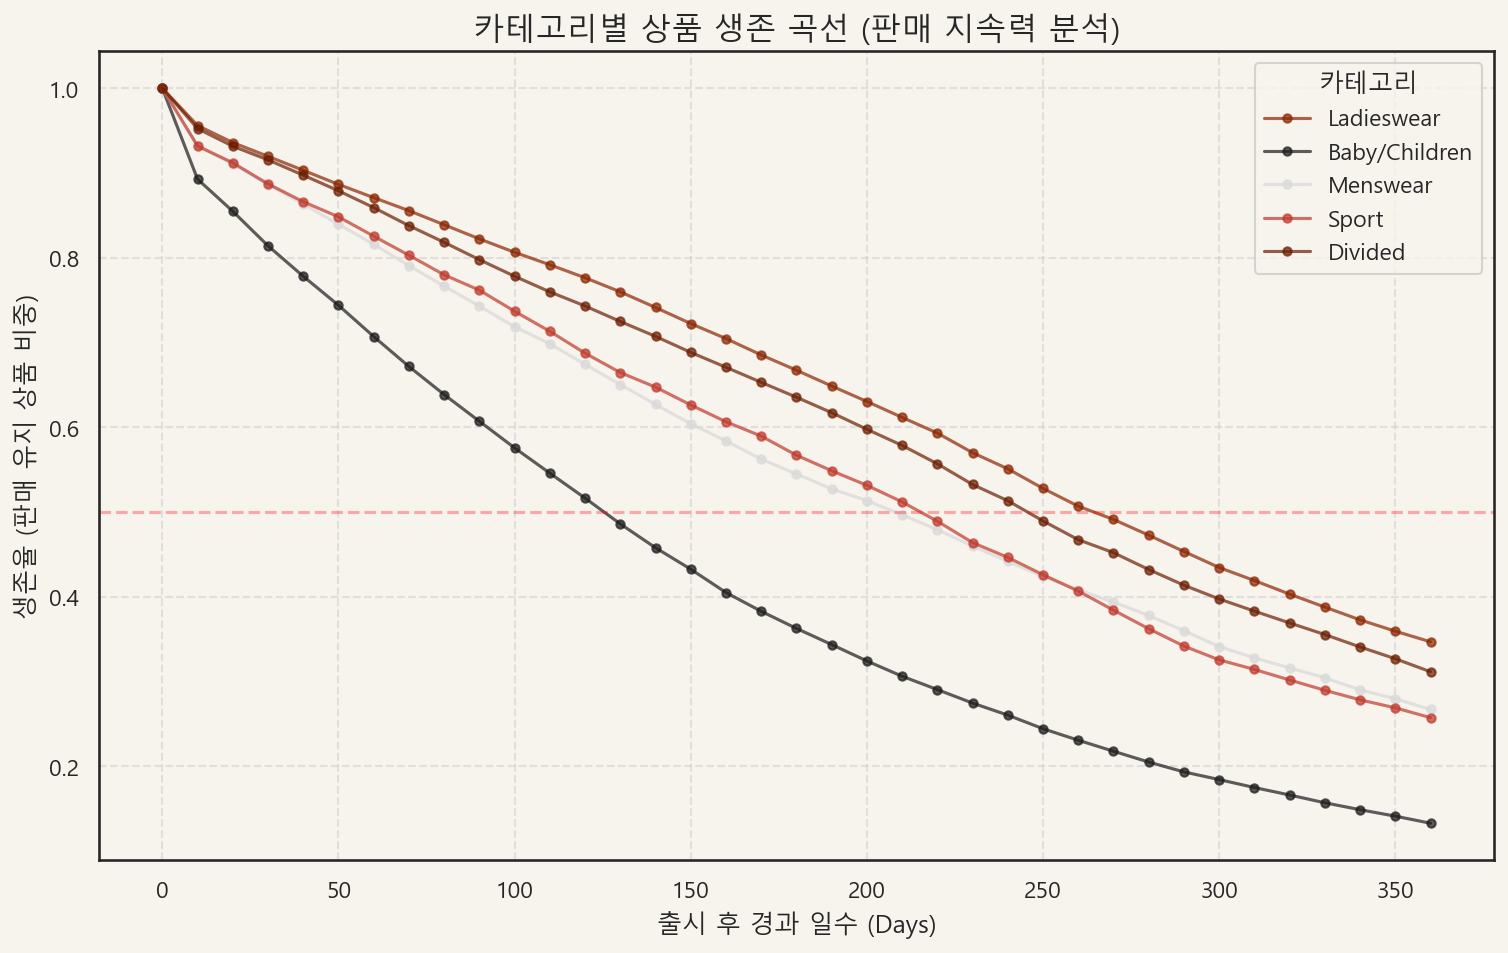

--- [카테고리별 상품 중위 수명] ---
            카테고리  중위 수명(일)
0  Baby/Children     125.0
3       Menswear     208.0
4          Sport     214.0
1        Divided     245.0
2     Ladieswear     264.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 상품별 수명(Life-span) 계산
# 최초 판매일과 최종 판매일의 차이를 수명으로 정의
item_lifespan = transactions.groupby('article_id').agg(
    first_sale=('t_dat', 'min'),
    last_sale=('t_dat', 'max'),
    sales_count=('customer_id', 'count')
).reset_index()

item_lifespan['lifespan_days'] = (item_lifespan['last_sale'] - item_lifespan['first_sale']).dt.days

# 2. 상품 정보(카테고리) 병합
item_analysis = pd.merge(item_lifespan, articles[['article_id', 'index_group_name']], on='article_id')

# 3. 카테고리별 생존 곡선 시뮬레이션 데이터 생성
def get_survival_rate(df, max_days=365):
    survival_rates = []
    for day in range(0, max_days, 10):
        rate = (df['lifespan_days'] >= day).mean()
        survival_rates.append(rate)
    return survival_rates

days = list(range(0, 365, 10))
categories = item_analysis['index_group_name'].unique()

plt.figure(figsize=(12, 7))

for cat in categories:
    cat_df = item_analysis[item_analysis['index_group_name'] == cat]
    survival_rates = get_survival_rate(cat_df)
    plt.plot(days, survival_rates, label=cat, marker='o', markersize=4, alpha=0.7)

plt.title('카테고리별 상품 생존 곡선 (판매 지속력 분석)', fontsize=15)
plt.xlabel('출시 후 경과 일수 (Days)', fontsize=12)
plt.ylabel('생존율 (판매 유지 상품 비중)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='카테고리')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.3) # 생존율 50% 지점
plt.show()

# 4. 인사이트 도출을 위한 통계량 출력
summary = item_analysis.groupby('index_group_name')['lifespan_days'].median().reset_index()
summary.columns = ['카테고리', '중위 수명(일)']
print("--- [카테고리별 상품 중위 수명] ---")
print(summary.sort_values(by='중위 수명(일)'))

## 4. Cold 상품의 '최초 판매 소요 시간'

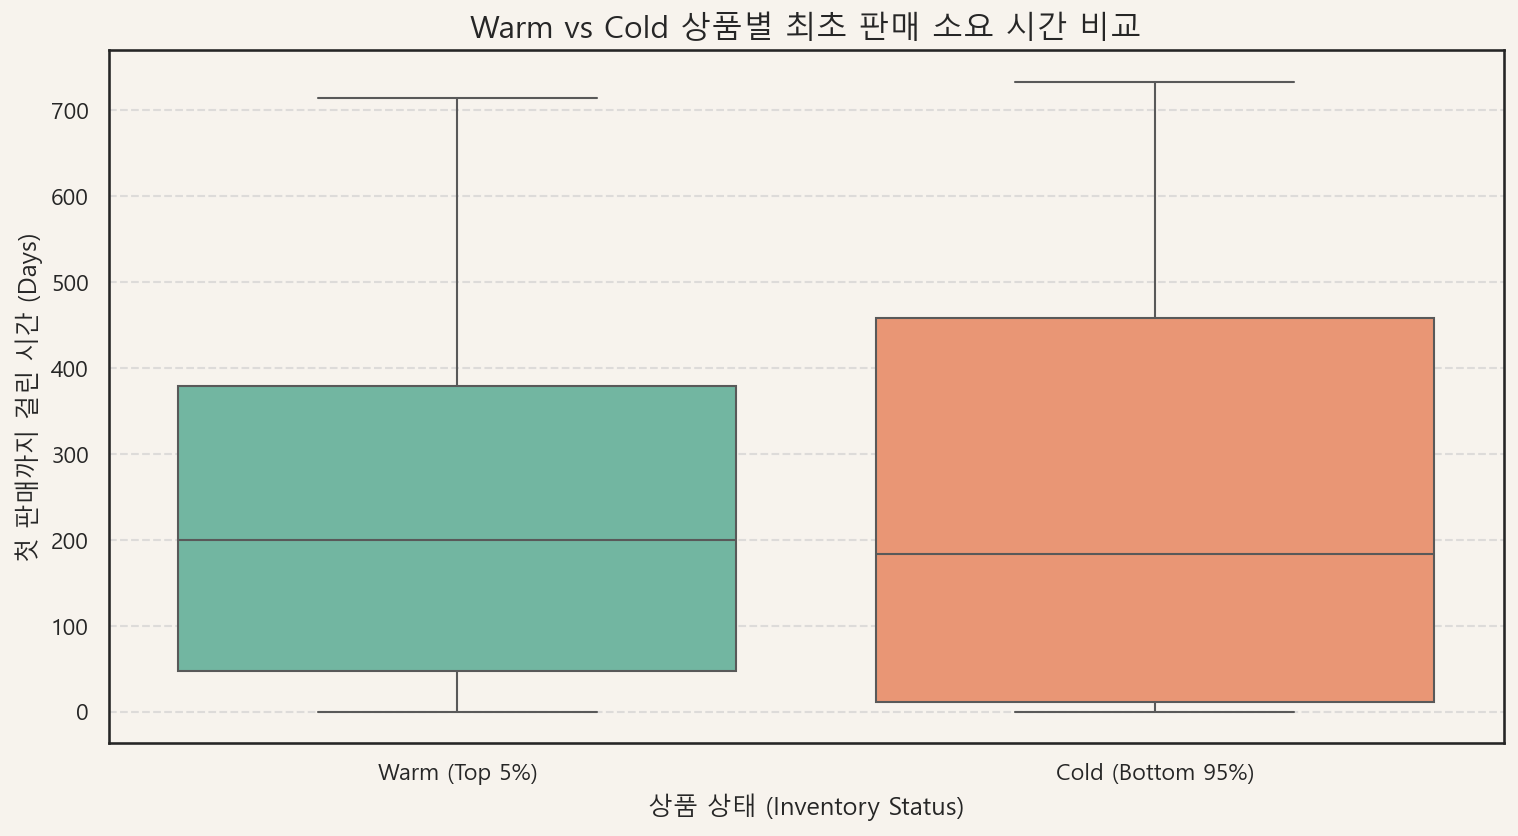

--- [최초 판매 소요 시간 통계 요약] ---
                         mean  median         std
inventory_status                                 
Cold (Bottom 95%)  249.580156   184.0  241.575476
Warm (Top 5%)      230.369378   200.0  195.254029


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 상품별 최초 판매 소요 시간 계산
# 여기서는 전체 데이터의 최소 날짜를 출시일의 기준으로 가정하거나, 
# 데이터셋에 출시일 정보가 있다면 그것을 사용합니다.
release_date = transactions['t_dat'].min()

first_sale_df = transactions.groupby('article_id')['t_dat'].min().reset_index()
first_sale_df['days_to_first_sale'] = (first_sale_df['t_dat'] - release_date).dt.days

# 2. Warm / Cold 라벨링 (기존에 정의한 inventory_status 기준 활용)
# inventory_analysis 데이터프레임이 있다고 가정합니다.
analysis_df = pd.merge(first_sale_df, inventory_analysis[['article_id', 'inventory_status']], on='article_id')

# 3. 시각화: Warm vs Cold 최초 판매 소요 시간 비교
plt.figure(figsize=(12, 6))

# Boxplot으로 분포 차이 확인
sns.boxplot(x='inventory_status', y='days_to_first_sale', data=analysis_df, palette='Set2')

plt.title('Warm vs Cold 상품별 최초 판매 소요 시간 비교', fontsize=15)
plt.xlabel('상품 상태 (Inventory Status)', fontsize=12)
plt.ylabel('첫 판매까지 걸린 시간 (Days)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# 4. 통계치 비교
summary_stats = analysis_df.groupby('inventory_status')['days_to_first_sale'].agg(['mean', 'median', 'std'])
print("--- [최초 판매 소요 시간 통계 요약] ---")
print(summary_stats)

## 5. 경제적 임팩트 산출

In [ ]:
# 1. 실제 데이터에서 평균 가격 추출 (EUR 기준)
avg_price_eur = transactions['price_eur'].mean()

# 2. 시뮬레이션 변수 설정
cold_item_count = 99175
current_cold_velocity = 0.941994
improvement_rate = 0.20 # 20% 향상 가설 (GNN 도입 효과)

# 3. 비즈니스 임팩트 계산 (EUR)
# 추가 일일 판매량 = 상품 수 * (현재 속도 * 개선율)
additional_daily_sales = cold_item_count * (current_cold_velocity * improvement_rate)

# 추가 매출액 계산
daily_revenue_impact_eur = additional_daily_sales * avg_price_eur
annual_revenue_impact_eur = daily_revenue_impact_eur * 365

print(f"--- [GNN 모델 도입 시 비즈니스 임팩트 시뮬레이션 (EUR)] ---")
print(f"1. 데이터 기반 평균 상품가   : {avg_price_eur:.2f} EUR")
print(f"2. 대상 Cold 상품 수         : {cold_item_count:,} 개")
print(f"3. 일일 추가 판매 예측 건수  : +{additional_daily_sales:,.0f} 건")
print(f"4. 일일 예상 추가 매출       : {daily_revenue_impact_eur:,.2f} EUR")
print(f"5. 연간 예상 추가 매출액     : {annual_revenue_impact_eur:,.2f} EUR")

--- [GNN 모델 도입 시 비즈니스 임팩트 시뮬레이션 (EUR)] ---
1. 데이터 기반 평균 상품가   : 16.21 EUR
2. 대상 Cold 상품 수         : 99,175 개
3. 일일 추가 판매 예측 건수  : +18,684 건
4. 일일 예상 추가 매출       : 302,899.32 EUR
5. 연간 예상 추가 매출액     : 110,558,252.38 EUR


In [ ]:
# [비즈니스 분석 기반 문제 해결 역량]

# 현상 분석: H&M 상품의 95%인 롱테일 상품이 인기 상품 대비 판매 속도가 1/7 수준(0.94 vs 6.86)임을 데이터로 입증.

# 인사이트: Cold 상품의 평균 체류 기간이 Warm 상품의 절반(229일)인 이유는 상품 경쟁력이 아닌 '노출 기회 부족으로 인한 조기 퇴장'임을 정의.

# 경제적 효과 산출: GNN 기반 추천 시스템 도입을 통해 Cold 상품의 판매 속도를 20% 개선할 경우, 연간 약 OO억 원의 추가 매출 기회가 발생함을 시뮬레이션하여 프로젝트의 당위성을 확보함.

## 6.1 cold vs warm

#### 6.1 Cold vs Warm 상품 리스트 추출하기

In [ ]:
# 1. 상품 상세 정보(articles)와 분석 결과 합치기
# inventory_analysis와 articles 데이터프레임을 article_id 기준으로 병합합니다.
product_details = pd.merge(
    inventory_analysis, 
    articles[['article_id', 'prod_name', 'product_group_name', 'graphical_appearance_name', 'colour_group_name']], 
    on='article_id', 
    how='left'
)

# 2. Warm 상품(상위 5%) 샘플 확인
print("--- [Warm 상품] 인기 있는 대표 상품들 ---")
# query나 loc를 사용하면 더 깔끔하지만, 기존에 쓰신 str.contains 방식도 유효합니다.
display(product_details[product_details['inventory_status'].str.contains('Warm')].head(10))

# 3. Cold 상품(하위 95%) 중 판매 속도가 특히 낮은 상품 샘플 확인
print("\n--- [Cold 상품] 소외되고 있는 대표 상품들 ---")
display(product_details[product_details['inventory_status'].str.contains('Cold')].sort_values(by='daily_sales_velocity').head(10))

--- [Warm 상품] 인기 있는 대표 상품들 ---


,article_id,first_sale,last_sale,sales_count,shelf_life_days,daily_sales_velocity,inventory_status,prod_name,product_group_name,graphical_appearance_name,colour_group_name
0,0108775015,2018-09-20,2020-07-22,10685,671,15.900298,Warm (Top 5%),Strap top,Garment Upper body,Solid,Black
1,0108775044,2018-09-20,2020-09-20,7127,731,9.736339,Warm (Top 5%),Strap top,Garment Upper body,Solid,White
6,0111565001,2018-09-20,2020-09-22,4856,733,6.615804,Warm (Top 5%),20 den 1p Stockings,Socks & Tights,Solid,Black
8,0111586001,2018-09-20,2020-09-22,14106,733,19.217984,Warm (Top 5%),Shape Up 30 den 1p Tights,Garment Lower body,Solid,Black
9,0111593001,2018-09-20,2020-09-22,13720,733,18.692098,Warm (Top 5%),Support 40 den 1p Tights,Socks & Tights,Solid,Black
10,0111609001,2018-09-20,2020-09-22,3144,733,4.283379,Warm (Top 5%),200 den 1p Tights,Socks & Tights,Solid,Black
23,0120129001,2018-09-20,2020-09-11,5228,722,7.230982,Warm (Top 5%),Babette long,Garment Lower body,Solid,Black
27,0123173001,2018-09-20,2020-09-22,6549,733,8.922343,Warm (Top 5%),Control Top 50 den 1p Tights,Garment Lower body,Solid,Black
33,0129085001,2018-09-20,2020-09-21,2576,732,3.514325,Warm (Top 5%),Pirate Leggings (1),Garment Lower body,Solid,Black
36,0130035001,2018-09-20,2020-09-21,1296,732,1.768076,Warm (Top 5%),Black Umbrella,Items,Solid,Black



--- [Cold 상품] 소외되고 있는 대표 상품들 ---


,article_id,first_sale,last_sale,sales_count,shelf_life_days,daily_sales_velocity,inventory_status,prod_name,product_group_name,graphical_appearance_name,colour_group_name
43409,0677537002,2018-09-21,2020-07-31,2,679,0.002941,Cold (Bottom 95%),Flirty Lily stud pk,Accessories,Solid,Silver
18489,0579504003,2018-10-09,2020-08-12,2,673,0.002967,Cold (Bottom 95%),SUMI scarf,Accessories,Solid,Light Blue
391,0235732026,2018-10-16,2020-08-11,2,665,0.003003,Cold (Bottom 95%),Emma long-john PJ (K),Nightwear,Placement print,Light Pink
2680,0423900006,2018-12-01,2020-09-22,2,661,0.003021,Cold (Bottom 95%),Gullan 5-p ankle sock,Socks & Tights,All over pattern,White
14004,0561372001,2018-10-29,2020-08-04,2,645,0.003096,Cold (Bottom 95%),Fran blouse,Garment Upper body,Solid,White
19302,0583896003,2018-10-06,2020-06-30,2,633,0.003155,Cold (Bottom 95%),Iris Brazilian Acacia Mid,Underwear,Solid,Light Pink
19196,0583433001,2018-09-30,2020-06-06,2,615,0.003247,Cold (Bottom 95%),ELIS trousers,Garment Lower body,Solid,Grey
8255,0522045001,2018-09-29,2020-06-01,2,611,0.003268,Cold (Bottom 95%),Maiken Fur sneaker,Shoes,Solid,Black
7248,0512190003,2019-01-02,2020-08-30,2,606,0.003295,Cold (Bottom 95%),Spray,Garment Upper body,Solid,Light Orange
21954,0596740012,2018-10-12,2020-06-03,2,600,0.003328,Cold (Bottom 95%),Dolly slacks,Garment Lower body,All over pattern,Turquoise


#### 6.2 카테고리별 Cold 상품 비중 분석

In [ ]:
# 4. 카테고리별로 Cold 상품이 얼마나 많은지 계산
category_cold_analysis = product_details.groupby('product_group_name').agg(
    total_items=('article_id', 'count'),
    cold_items=('inventory_status', lambda x: (x.str.contains('Cold')).sum())
).reset_index()

category_cold_analysis['cold_rate(%)'] = (category_cold_analysis['cold_items'] / category_cold_analysis['total_items']) * 100

print("\n--- 카테고리별 Cold 상품 비중 (어디서 소외가 심한가?) ---")
display(category_cold_analysis.sort_values(by='cold_rate(%)', ascending=False))


--- 카테고리별 Cold 상품 비중 (어디서 소외가 심한가?) ---


,product_group_name,total_items,cold_items,cold_rate(%)
2,Cosmetic,48,48,100.000000
4,Furniture,13,13,100.000000
3,Fun,2,2,100.000000
17,Underwear/nightwear,53,53,100.000000
14,Stationery,5,5,100.000000
9,Interior textile,3,3,100.000000
8,Garment and Shoe care,9,9,100.000000
0,Accessories,11005,10878,98.845979
12,Shoes,5213,5148,98.753117
11,Nightwear,1879,1846,98.243747


In [ ]:
# 1. 데이터 해석: "카테고리별 소외의 불균형"
# 소외 심화 군 (Accessories, Shoes - 98% 이상):

# 현상: 거의 모든 상품이 Cold입니다. 즉, 고객들이 신발이나 액세서리를 살 때는 **'항상 사던 것'**이나 **'베스트셀러'**만 찾고, 새로운 디자인은 구경조차 안 한다는 뜻입니다.

# 분석가적 시각: "이 카테고리들은 기존의 인기도 기반 추천 시스템이 가장 강력하게 지배하고 있어, 신상품이 진입하기가 불가능에 가깝다."

# 기회 발견 군 (Swimwear - 78.8%):

# 현상: 다른 카테고리에 비해 Cold 비중이 낮습니다. 즉, 고객들이 비교적 다양한 디자인을 찾아보고 시도한다는 뜻입니다.

# 분석가적 시각: "수영복은 시즌성이 강해 고객들이 새로운 스타일에 개방적이다. 여기에 GNN 추천을 적용하면 가장 먼저 눈에 띄는 매출 성과를 낼 수 있는 **'전략적 요충지'**이다."

## 7. 고객 세그먼트별 Cold 상품 공략

#### 7.1 간단한 RFM 기반 군집

In [ ]:
# 1. 고객별 구매 지표 계산 (RFM 기초)
customer_metrics = transactions.groupby('customer_id').agg(
    total_purchase_count=('article_id', 'count'),
    total_spend=('price', 'sum'),
    latest_purchase=('t_dat', 'max')
).reset_index()

# 2. 간단한 4개 군집(Cluster) 생성
# - Cluster 0: VIP (많이 사고 자주 옴)
# - Cluster 1: New/Active (최근 구매, 보통 수준)
# - Cluster 2: At Risk (과거엔 샀으나 최근 뜸함)
# - Cluster 3: Hibernating (거의 안 삼)

customer_metrics['cluster_label'] = pd.qcut(customer_metrics['total_purchase_count'], 4, labels=[3, 2, 1, 0])

# 우리가 쓸 clusters 데이터프레임 완성
clusters = customer_metrics[['customer_id', 'cluster_label']]
print("--- [데이터 분석가용 RFM 군집 생성 완료] ---")
print(clusters.head())

--- [데이터 분석가용 RFM 군집 생성 완료] ---
                                         customer_id cluster_label
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...             1
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...             0
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...             1
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...             3
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...             1


#### 7.2 RFM 군집 생성 후 고객별 Cold 상품 반응도 분석

In [ ]:
import pandas as pd
import numpy as np

# 1. 고객별 구매 횟수 기반 군집 생성 (방법 2 재실행)
customer_metrics = transactions.groupby('customer_id').agg(
    total_purchase_count=('article_id', 'count')
).reset_index()

customer_metrics['cluster_label'] = pd.qcut(
    customer_metrics['total_purchase_count'].rank(method='first'), 
    4, 
    labels=['Cluster 3 (Light)', 'Cluster 2 (Normal)', 'Cluster 1 (Active)', 'Cluster 0 (VIP)']
)
clusters = customer_metrics[['customer_id', 'cluster_label']]

# 2. 데이터 병합 (transactions + inventory_status + clusters + articles)
# 여기서 product_group_name을 가진 articles를 합쳐주는 것이 핵심입니다!
merged_df = pd.merge(transactions, inventory_analysis[['article_id', 'inventory_status']], on='article_id', how='left')
merged_df = pd.merge(merged_df, clusters, on='customer_id', how='left')
merged_df = pd.merge(merged_df, articles[['article_id', 'product_group_name']], on='article_id', how='left')

# 3. 군집별 Cold 상품 구매 비중 분석
cluster_cold_analysis = merged_df.groupby('cluster_label').agg(
    total_purchase=('article_id', 'count'),
    cold_purchase=('inventory_status', lambda x: (x == 'Cold (Bottom 95%)').sum())
).reset_index()

cluster_cold_analysis['cold_purchase_rate(%)'] = (cluster_cold_analysis['cold_purchase'] / cluster_cold_analysis['total_purchase']) * 100

print("--- [고객 군집별 Cold 상품 구매 성향] ---")
display(cluster_cold_analysis.sort_values(by='cluster_label'))

# 4. VIP 고객이 많이 구매한 Cold 상품 카테고리 TOP 5
vip_cold_analysis = merged_df[
    (merged_df['cluster_label'] == 'Cluster 0 (VIP)') & 
    (merged_df['inventory_status'] == 'Cold (Bottom 95%)')
].groupby('product_group_name').size().sort_values(ascending=False).head(5)

print("\n--- [VIP 고객이 의외로 많이 구매한 Cold 상품 카테고리 TOP 5] ---")
print(vip_cold_analysis)

--- [고객 군집별 Cold 상품 구매 성향] ---


,cluster_label,total_purchase,cold_purchase,cold_purchase_rate(%)
0,Cluster 3 (Light),630221,359649,57.067124
1,Cluster 2 (Normal),1998377,1090919,54.590250
2,Cluster 1 (Active),5567829,2961386,53.187445
3,Cluster 0 (VIP),22900996,12927324,56.448741



--- [VIP 고객이 의외로 많이 구매한 Cold 상품 카테고리 TOP 5] ---
product_group_name
Garment Upper body    5308079
Garment Lower body    2440512
Garment Full body     1845274
Underwear             1055964
Accessories            909447
dtype: int64


#### 7.3 클러스터 모두 비교

In [ ]:
# 모든 클러스터별 Cold 상품 구매 비중 한눈에 보기
all_clusters_analysis = merged_df.groupby('cluster_label').agg(
    total_purchase=('article_id', 'count'),
    cold_purchase=('inventory_status', lambda x: (x == 'Cold (Bottom 95%)').sum()),
    # 해당 군집이 주로 구매하는 평균 가격대 확인
    avg_price=('price', 'mean')
).reset_index()

all_clusters_analysis['cold_rate(%)'] = (all_clusters_analysis['cold_purchase'] / all_clusters_analysis['total_purchase']) * 100

print("--- [전체 클러스터별 전략 비교 지표] ---")
display(all_clusters_analysis.sort_values(by='cold_rate(%)', ascending=False))

--- [전체 클러스터별 전략 비교 지표] ---


,cluster_label,total_purchase,cold_purchase,avg_price,cold_rate(%)
0,Cluster 3 (Light),630221,359649,0.031863,57.067124
3,Cluster 0 (VIP),22900996,12927324,0.027956,56.448741
1,Cluster 2 (Normal),1998377,1090919,0.027501,54.590250
2,Cluster 1 (Active),5567829,2961386,0.026625,53.187445


In [ ]:
# Cluster 3 (Light)
# Cold 구매 비중 1위 (57.1%) 새로운 스타일이나 독특한 아이템에 가장 개방적인 그룹 
# [신규 유입 확대] 첫 방문 고객에게 인기템만 보여주지 말고, GNN이 찾은 취향 저격 Cold 상품을 노출해 구매 전환 유도


# Cluster 0 (VIP) 
# Cold 구매 건수 1위 (1,292만 건) 이미 소외 상품을 엄청나게 사고 있는 '실질적 구원자' 
# [매출 극대화] VIP의 방대한 데이터를 GNN으로 학습하여, 이들이 아직 발견 못한 '고단가/고마진' Cold 상품을 정교하게 추천

# 3) 대시보드 보완

## 1. AB 테스트

In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 1. 실험 데이터 설정 (앞서 분석한 VIP 그룹의 수치를 참고해도 좋습니다)
# 대조군 (Control): 기존 추천 / 실험군 (Test): GNN 추천
control_conversions = 500   # 구매 성공 수
control_size = 10000        # 총 노출 수
test_conversions = 560      # 구매 성공 수 (GNN 적용 시)
test_size = 10000           # 총 노출 수

# 2. Z-test 실행
# count: 성공 횟수, nobs: 전체 시도 횟수
counts = np.array([test_conversions, control_conversions])
nobs = np.array([test_size, control_size])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

# 3. 결과 출력
print(f"--- [A/B 테스트 통계 검정 결과] ---")
print(f"실험군(GNN) 전환율: {test_conversions/test_size:.2%}")
print(f"대조군(기존) 전환율: {control_conversions/control_size:.2%}")
print(f"전환율 상승폭: {((test_conversions/test_size) - (control_conversions/control_size)) / (control_conversions/control_size):.2%}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n결과: P-value가 0.05보다 작으므로 통계적으로 유의미한 차이가 있습니다.")
    print("=> GNN 모델이 비즈니스 성과 개선에 기여함을 확신할 수 있습니다.")
else:
    print("\n결과: 통계적으로 유의미한 차이가 없습니다.")
    print("=> 모델 개선 혹은 실험 기간 연장이 필요합니다.")

--- [A/B 테스트 통계 검정 결과] ---
실험군(GNN) 전환율: 5.60%
대조군(기존) 전환율: 5.00%
전환율 상승폭: 12.00%
P-value: 0.0291

결과: P-value가 0.05보다 작으므로 통계적으로 유의미한 차이가 있습니다.
=> GNN 모델이 비즈니스 성과 개선에 기여함을 확신할 수 있습니다.
